# International Country Portfolios — Trend-Following Strategy

For each country portfolio we run a monthly 12-1 time-series momentum
strategy: invest in the asset when the 11-month return ending one month ago
is positive; otherwise hold cash (zero return).  Only countries whose data
begins at the earliest available date are included, matching the filter in
the performance analysis notebook.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display, Image
from fmr.paths import ProjPaths
from fmr.finance import (
    compute_drawdowns,
    compute_annualized_returns,
    compute_individual_drawdowns,
    compute_worst_drawdown_stats,
    compute_ts_momentum_strategy,
    compute_strategy_turnover,
)

paths = ProjPaths()
prices_all = pd.read_csv(
    paths.countries_synth_prices_path, index_col="date", parse_dates=True
)
first_dates = prices_all.apply(lambda s: s.first_valid_index())
prices = prices_all.loc[:, first_dates == first_dates.min()].dropna()

## Build strategy prices

In [2]:
strategy_prices = pd.DataFrame(index=prices.index)
invested_flags = pd.DataFrame(index=prices.index)

for col in prices.columns:
    result = compute_ts_momentum_strategy(prices[col])
    strategy_prices[col] = result["strategy_price"]
    invested_flags[col] = result["invested"]

## Risk–return metrics

In [3]:
ann_ret_orig = compute_annualized_returns(prices)
max_dd_orig = compute_drawdowns(prices).max()
dd_stats_orig = compute_worst_drawdown_stats(compute_individual_drawdowns(prices), ns=[5])
avg5_dd_orig = dd_stats_orig["avg_max_dd_5"].reindex(prices.columns)

ann_ret_strat = compute_annualized_returns(strategy_prices)
max_dd_strat = compute_drawdowns(strategy_prices).max()
dd_stats_strat = compute_worst_drawdown_stats(compute_individual_drawdowns(strategy_prices), ns=[5])
avg5_dd_strat = dd_stats_strat["avg_max_dd_5"].reindex(prices.columns)

## Scatterplots: buy-and-hold vs trend-following

### Annualized return vs maximum drawdown

In [4]:
fig, ax = plt.subplots(figsize=(10, 7))

for col in prices.columns:
    ax.plot(
        [max_dd_orig[col], max_dd_strat[col]],
        [ann_ret_orig[col], ann_ret_strat[col]],
        color="gray", linewidth=0.7, alpha=0.5, zorder=1,
    )

ax.scatter(max_dd_orig, ann_ret_orig, s=60, color="steelblue", zorder=3, label="Buy & hold")
ax.scatter(max_dd_strat, ann_ret_strat, s=60, color="darkorange", zorder=3, label="12-1 Momentum")
for col in prices.columns:
    ax.annotate(col, (max_dd_orig[col], ann_ret_orig[col]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)

ax.set_xlabel("Maximum drawdown (%)")
ax.set_ylabel("Annualized return (%)")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_risk_return.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/921314824.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_risk_return.png
:name: fig-07-country-tf-risk-return
Annualized return vs maximum drawdown for buy-and-hold (blue) and the 12-1
time-series momentum strategy (orange) across the 14 country portfolios.
Gray lines connect each country to its corresponding strategy.
```

### Annualized return vs average of 5 worst drawdowns

In [5]:
fig, ax = plt.subplots(figsize=(10, 7))

for col in prices.columns:
    ax.plot(
        [avg5_dd_orig[col], avg5_dd_strat[col]],
        [ann_ret_orig[col], ann_ret_strat[col]],
        color="gray", linewidth=0.7, alpha=0.5, zorder=1,
    )

ax.scatter(avg5_dd_orig, ann_ret_orig, s=60, color="steelblue", zorder=3, label="Buy & hold")
ax.scatter(avg5_dd_strat, ann_ret_strat, s=60, color="darkorange", zorder=3, label="12-1 Momentum")
for col in prices.columns:
    ax.annotate(col, (avg5_dd_orig[col], ann_ret_orig[col]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)

ax.set_xlabel("Average max drawdown — 5 worst episodes (%)")
ax.set_ylabel("Annualized return (%)")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_dd_return.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/1432310539.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_dd_return.png
:name: fig-07-country-tf-dd-return
Annualized return vs average of the 5 worst drawdowns for buy-and-hold (blue)
and the 12-1 time-series momentum strategy (orange).
Gray lines connect each country to its corresponding strategy.
```

### Strategy vs constant-weight benchmark

The momentum strategy is only partially invested on average, so it naturally
carries less risk than buy-and-hold.  To isolate the value of timing, we
compare it against a static portfolio that holds the same average weight in
the risky asset for the entire period.

In [6]:
static_prices = pd.DataFrame(index=prices.index)
for col in prices.columns:
    w = invested_flags[col].mean()
    asset_ret = prices[col].pct_change().fillna(0.0)
    static_prices[col] = (1.0 + w * asset_ret).cumprod()

ann_ret_static = compute_annualized_returns(static_prices)
max_dd_static  = compute_drawdowns(static_prices).max()
dd_stats_static = compute_worst_drawdown_stats(compute_individual_drawdowns(static_prices), ns=[5])
avg5_dd_static = dd_stats_static["avg_max_dd_5"].reindex(prices.columns)

In [7]:
fig, ax = plt.subplots(figsize=(10, 7))

for col in prices.columns:
    ax.plot(
        [max_dd_static[col], max_dd_strat[col]],
        [ann_ret_static[col], ann_ret_strat[col]],
        color="gray", linewidth=0.7, alpha=0.5, zorder=1,
    )

ax.scatter(max_dd_static, ann_ret_static, s=60, color="seagreen", zorder=3, label="Constant weight")
ax.scatter(max_dd_strat, ann_ret_strat, s=60, color="darkorange", zorder=3, label="12-1 Momentum")
for col in prices.columns:
    ax.annotate(col, (max_dd_static[col], ann_ret_static[col]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)

ax.set_xlabel("Maximum drawdown (%)")
ax.set_ylabel("Annualized return (%)")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_cw_risk_return.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/2371870361.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_cw_risk_return.png
:name: fig-07-country-tf-cw-risk-return
Annualized return vs maximum drawdown for the constant-weight benchmark (green)
and the 12-1 momentum strategy (orange).  Each constant-weight portfolio holds
the same average risky-asset fraction as its paired momentum strategy, so any
difference reflects pure timing skill.  Gray lines connect each pair.
```

In [8]:
fig, ax = plt.subplots(figsize=(10, 7))

for col in prices.columns:
    ax.plot(
        [avg5_dd_static[col], avg5_dd_strat[col]],
        [ann_ret_static[col], ann_ret_strat[col]],
        color="gray", linewidth=0.7, alpha=0.5, zorder=1,
    )

ax.scatter(avg5_dd_static, ann_ret_static, s=60, color="seagreen", zorder=3, label="Constant weight")
ax.scatter(avg5_dd_strat, ann_ret_strat, s=60, color="darkorange", zorder=3, label="12-1 Momentum")
for col in prices.columns:
    ax.annotate(col, (avg5_dd_static[col], ann_ret_static[col]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)

ax.set_xlabel("Average max drawdown — 5 worst episodes (%)")
ax.set_ylabel("Annualized return (%)")
ax.legend()
ax.grid(True, linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_cw_dd_return.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/640473326.py:22: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_cw_dd_return.png
:name: fig-07-country-tf-cw-dd-return
Annualized return vs average of the 5 worst drawdowns for the constant-weight
benchmark (green) and the 12-1 momentum strategy (orange).
Gray lines connect each pair.
```

### Asset return vs strategy return

In [9]:
lim_ret = [min(ann_ret_orig.min(), ann_ret_strat.min()) - 0.5,
           max(ann_ret_orig.max(), ann_ret_strat.max()) + 0.5]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(lim_ret, lim_ret, color="gray", linewidth=0.8, linestyle="--", zorder=1)
ax.scatter(ann_ret_orig, ann_ret_strat, s=60, color="steelblue", zorder=3)
for col in prices.columns:
    ax.annotate(col, (ann_ret_orig[col], ann_ret_strat[col]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.set_xlabel("Buy & hold annualized return (%)")
ax.set_ylabel("Strategy annualized return (%)")
ax.grid(True, linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_ret_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/3183391029.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_ret_scatter.png
:name: fig-07-country-tf-ret-scatter
Annualized return of buy-and-hold (x) vs the 12-1 momentum strategy (y).
Points above the diagonal indicate the strategy outperformed.
```

### Asset avg-5-drawdown vs strategy avg-5-drawdown

In [10]:
lim_dd = [min(avg5_dd_orig.min(), avg5_dd_strat.min()) - 1,
          max(avg5_dd_orig.max(), avg5_dd_strat.max()) + 1]

fig, ax = plt.subplots(figsize=(8, 8))
ax.plot(lim_dd, lim_dd, color="gray", linewidth=0.8, linestyle="--", zorder=1)
ax.scatter(avg5_dd_orig, avg5_dd_strat, s=60, color="steelblue", zorder=3)
for col in prices.columns:
    ax.annotate(col, (avg5_dd_orig[col], avg5_dd_strat[col]),
                textcoords="offset points", xytext=(5, 3), fontsize=7)
ax.set_xlabel("Buy & hold avg 5 worst drawdowns (%)")
ax.set_ylabel("Strategy avg 5 worst drawdowns (%)")
ax.grid(True, linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_dd_scatter.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/4264814645.py:15: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_dd_scatter.png
:name: fig-07-country-tf-dd-scatter
Average of the 5 worst drawdowns for buy-and-hold (x) vs the momentum strategy (y).
Points below the diagonal indicate the strategy reduced drawdown risk.
```

## Fraction of days invested

### Overall fraction invested per country

In [11]:
frac_invested = invested_flags.mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
frac_invested.plot(kind="barh", ax=ax, color="steelblue", width=0.7)
ax.set_xlabel("Fraction of months invested in risky asset")
ax.axvline(frac_invested.mean(), color="firebrick", linewidth=1, linestyle="--",
           label=f"Mean ({frac_invested.mean():.2f})")
ax.legend()
ax.grid(True, axis="x", linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_frac_invested_bar.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/2136314403.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_frac_invested_bar.png
:name: fig-07-country-tf-frac-invested-bar
Fraction of months the 12-1 momentum strategy is invested in each country
portfolio, sorted ascending.  The dashed line marks the cross-country mean.
```

### Yearly fraction invested per country

In [12]:
yearly_frac = (
    invested_flags.astype(float).groupby(invested_flags.index.year).mean() * 100
)

fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(
    yearly_frac.T,
    ax=ax,
    cmap="Blues",
    vmin=0,
    vmax=100,
    linewidths=0.3,
    cbar_kws={"label": "Months invested (%)"},
)
ax.set_xlabel("Year")
ax.set_ylabel("Country")
ax.tick_params(axis="x", labelsize=7, rotation=90)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_invested_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/6957970.py:20: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_invested_heatmap.png
:name: fig-07-country-tf-invested-heatmap
Percentage of months per calendar year that the momentum strategy is invested
in each country.  100 % = fully invested all year; 0 % = cash all year.
```

## Strategy turnover

Each transition between invested and cash (or back) is one 100% trade.
Turnover = total trade volume / 2, annualized.

In [13]:
turnover = compute_strategy_turnover(invested_flags).sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
turnover.plot(kind="barh", ax=ax, color="steelblue", width=0.7)
ax.set_xlabel("Annualized turnover (% per year)")
ax.axvline(turnover.mean(), color="firebrick", linewidth=1, linestyle="--",
           label=f"Mean ({turnover.mean():.1f}%)")
ax.legend()
ax.grid(True, axis="x", linewidth=0.4, alpha=0.6)
fig.tight_layout()
fig.savefig(paths.images_path / "07_country_tf_turnover_bar.png", dpi=150, bbox_inches="tight")
plt.show()

/tmp/ipykernel_552142/204455688.py:12: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


```{figure} ../../output/images/07_country_tf_turnover_bar.png
:name: fig-07-country-tf-turnover-bar
Annualized strategy turnover for each country portfolio.  One full
invested→cash or cash→invested transition equals 100% trade volume;
turnover is total trade volume divided by 2, annualized.
```

## Per-asset price and drawdown charts

Each panel shows (top) the log-scale price of the buy-and-hold series vs the
momentum strategy, and (bottom) their respective drawdowns over time.

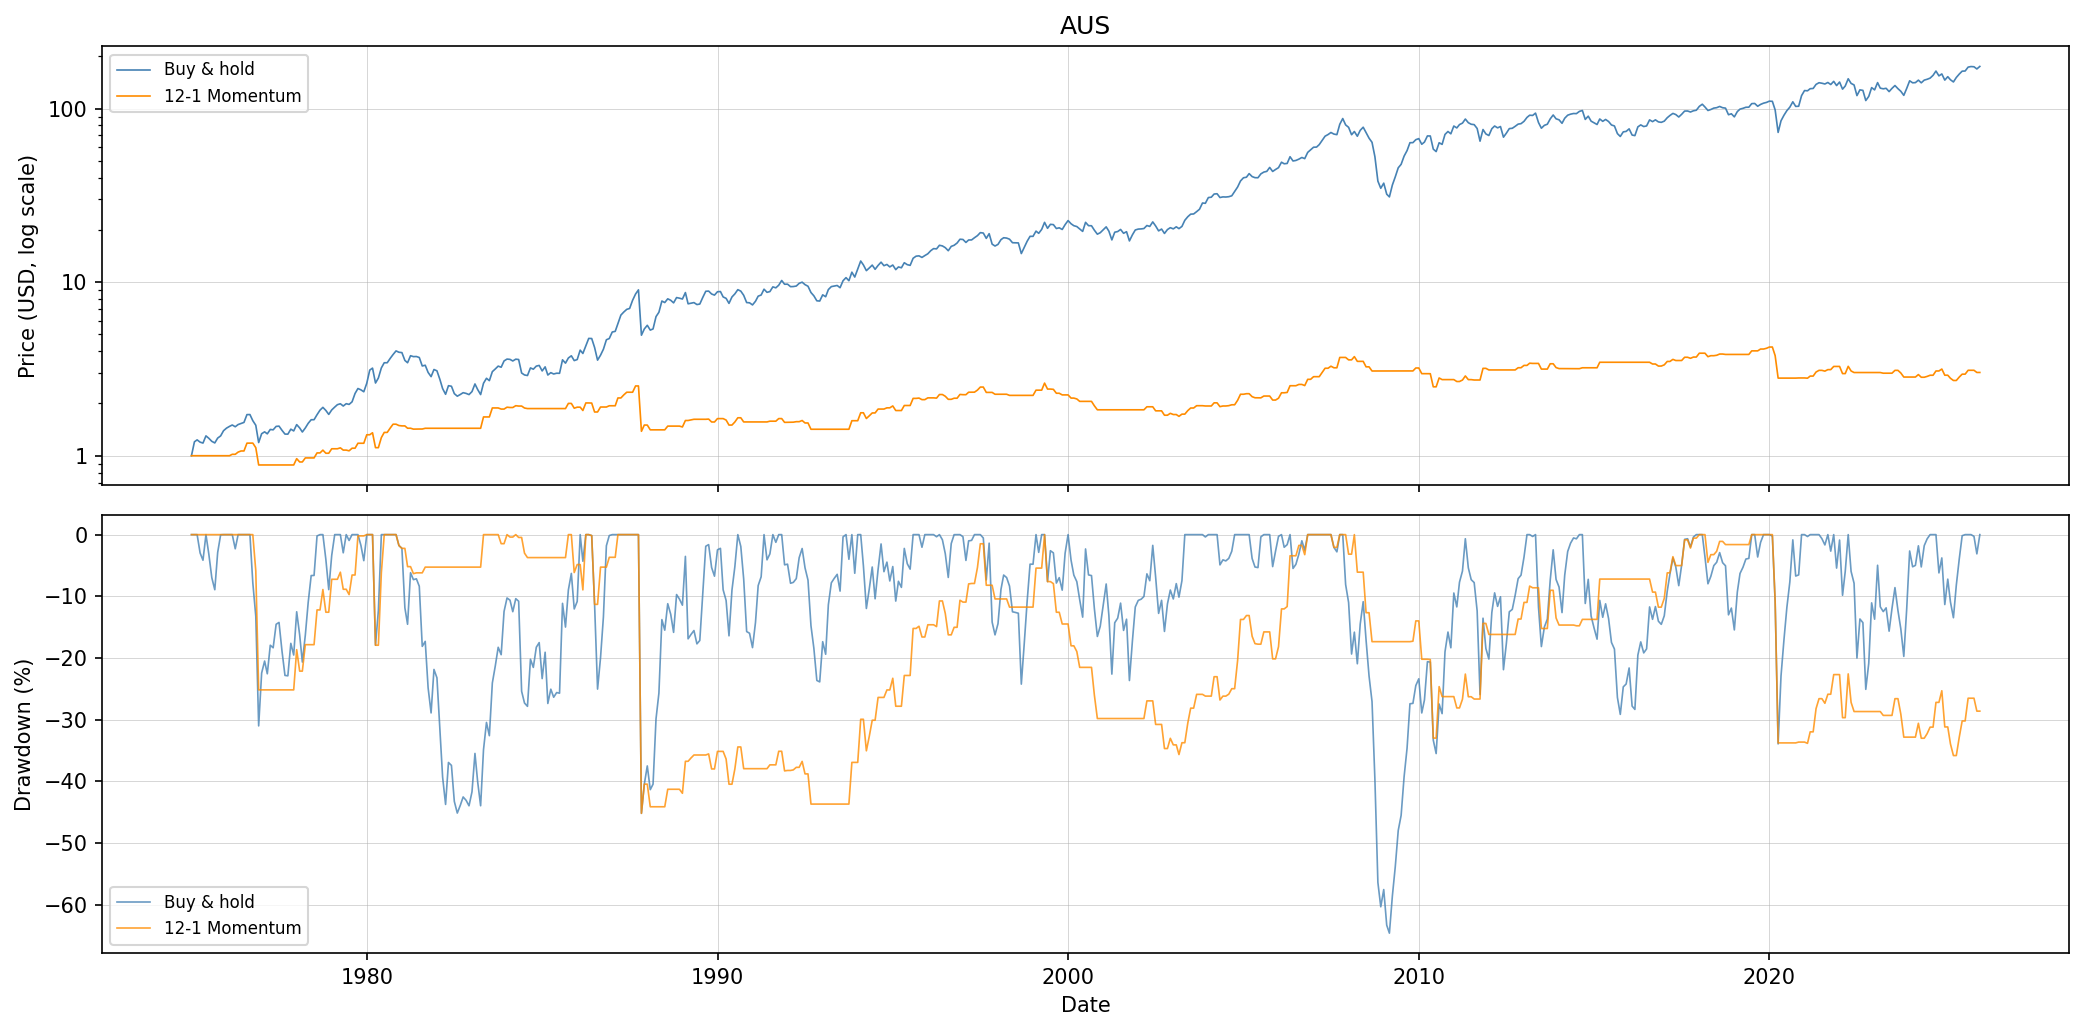

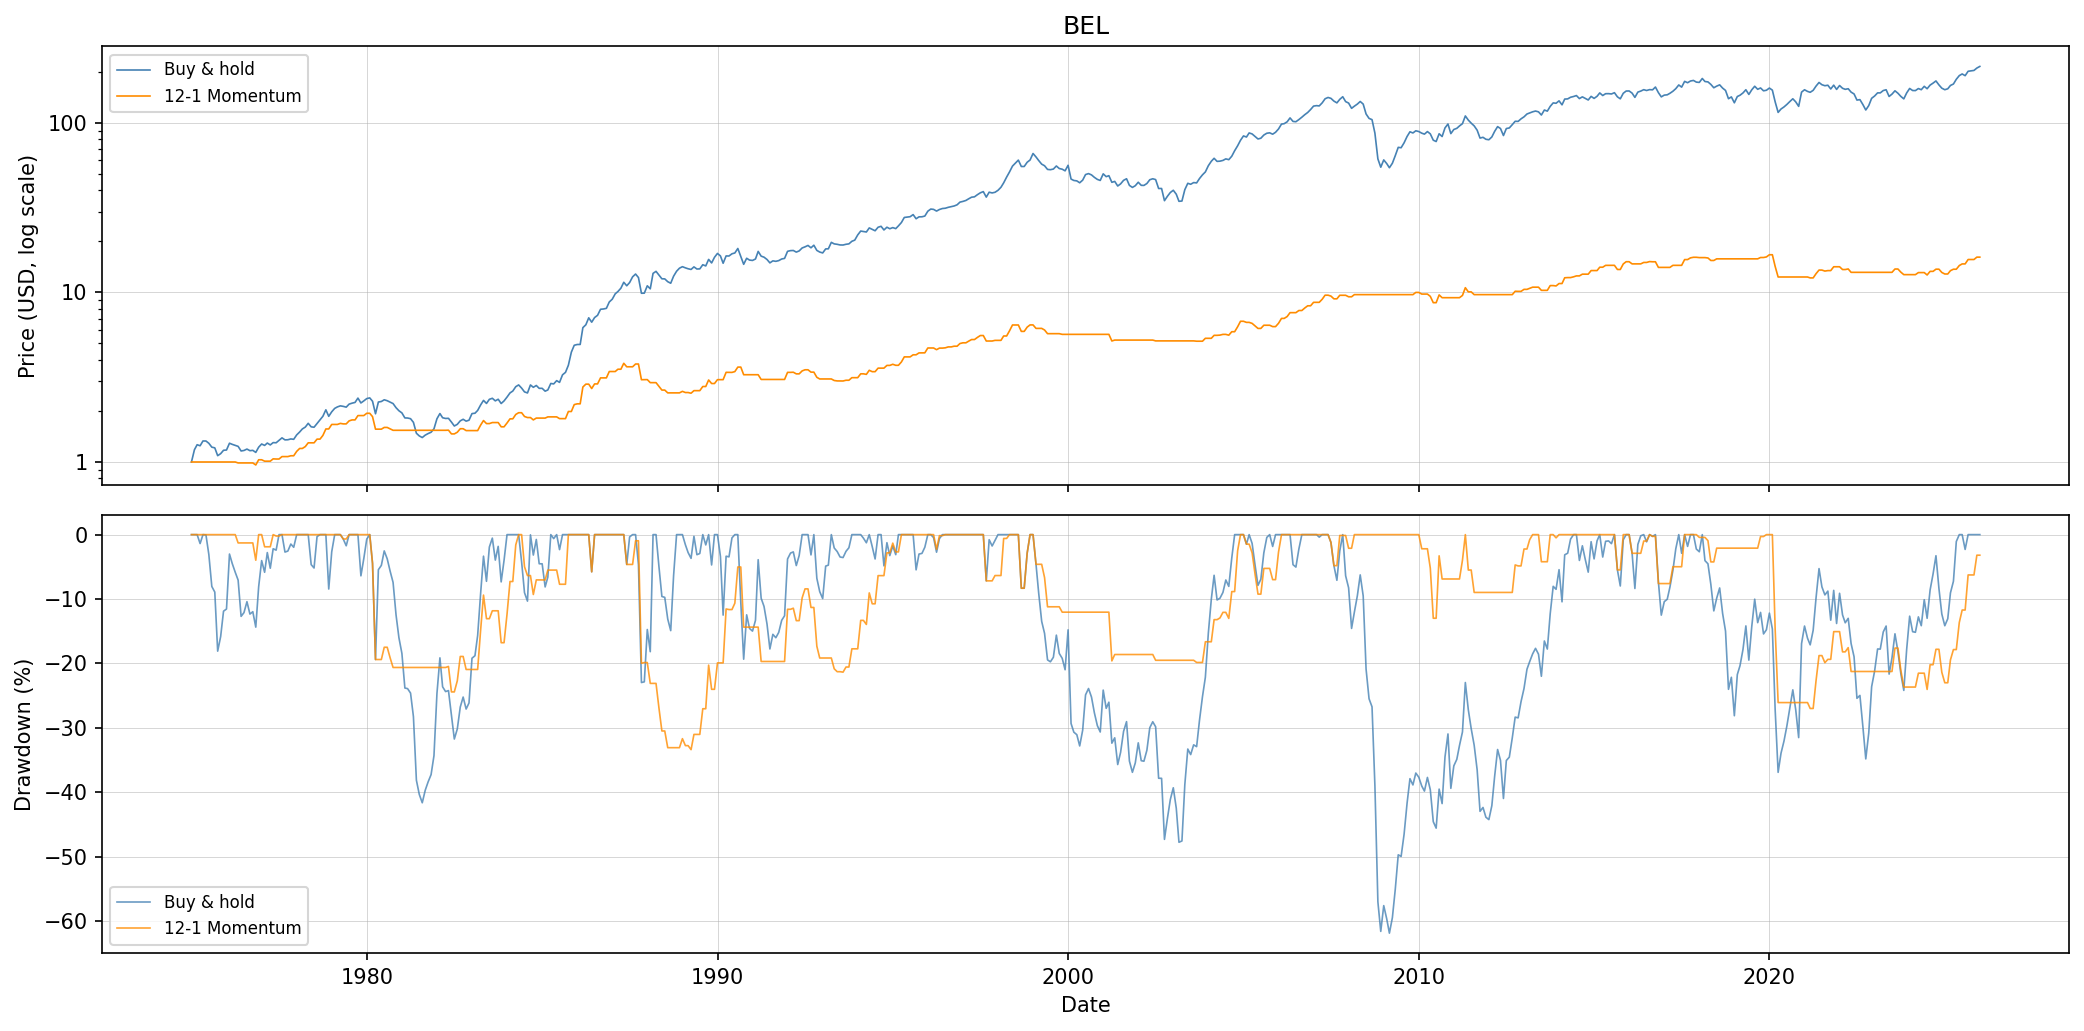

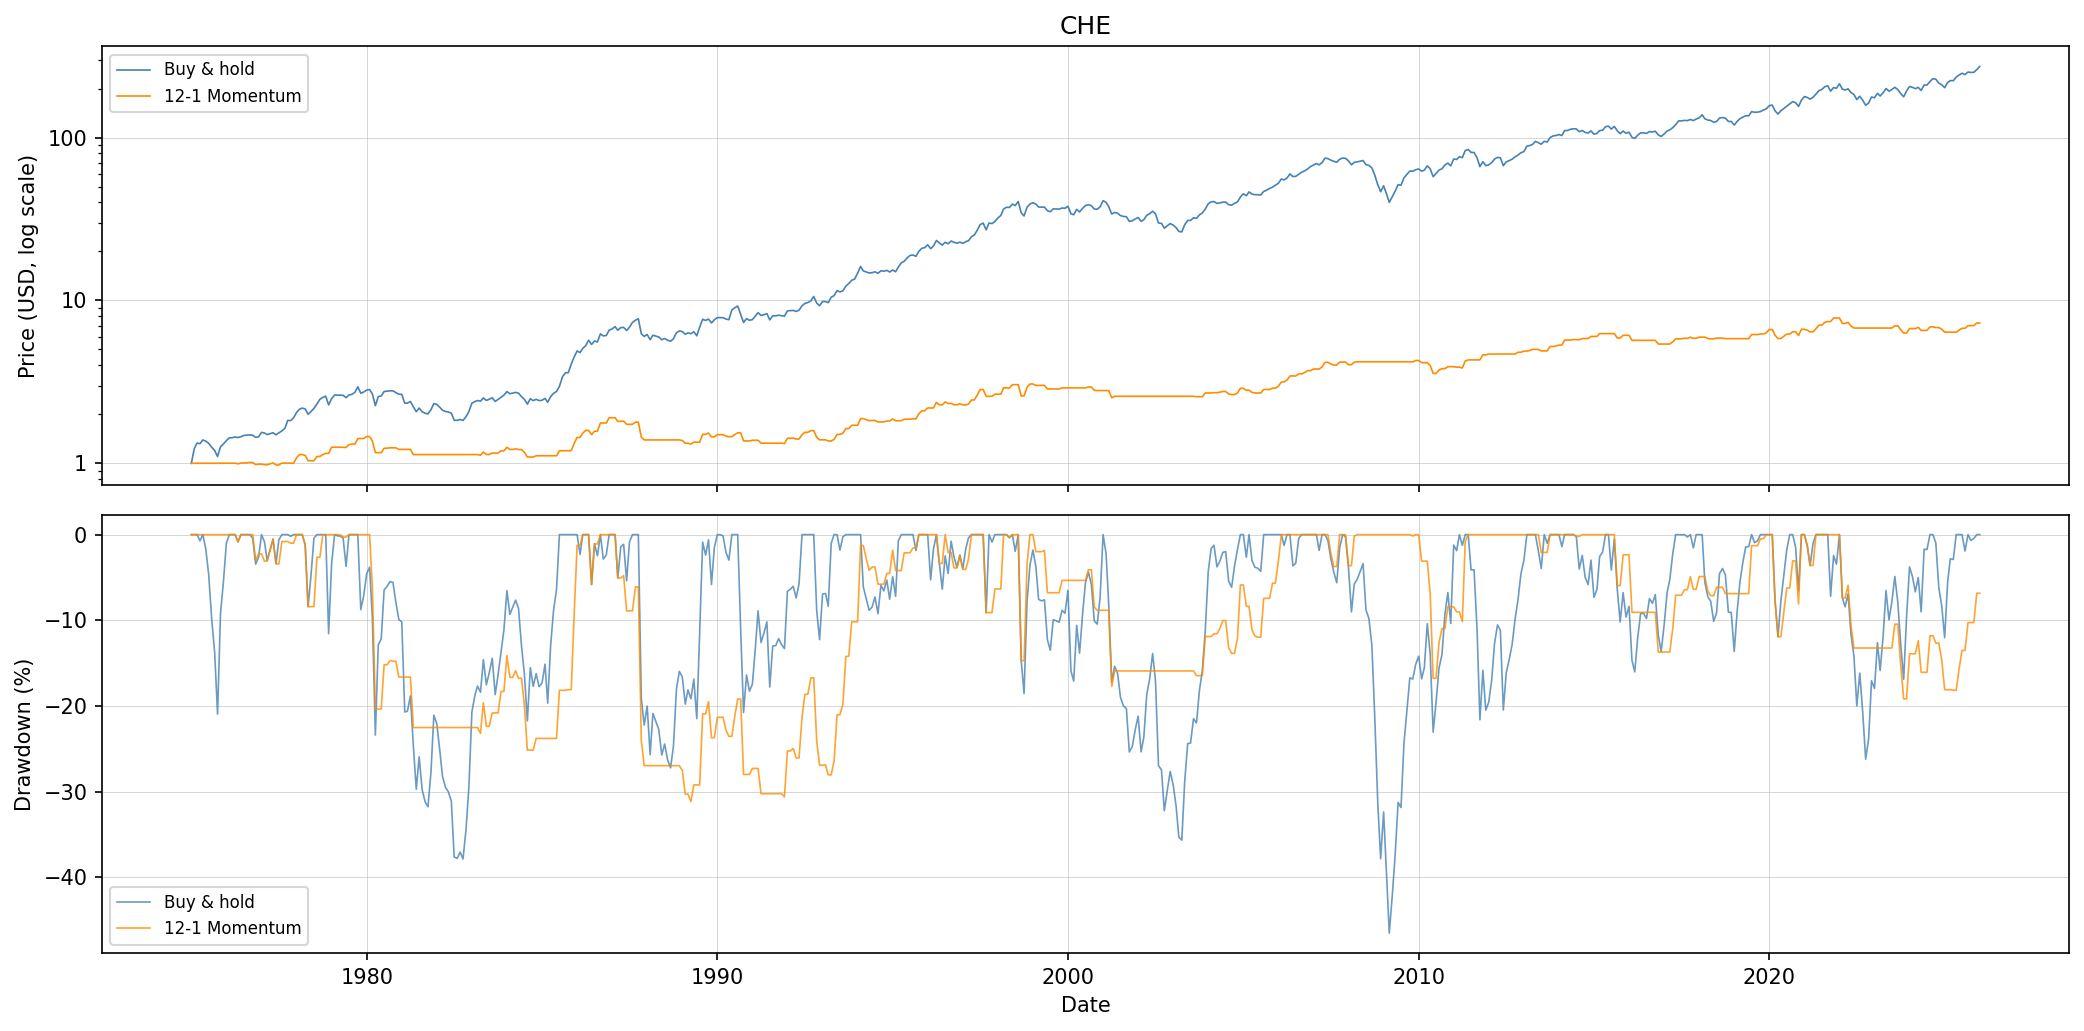

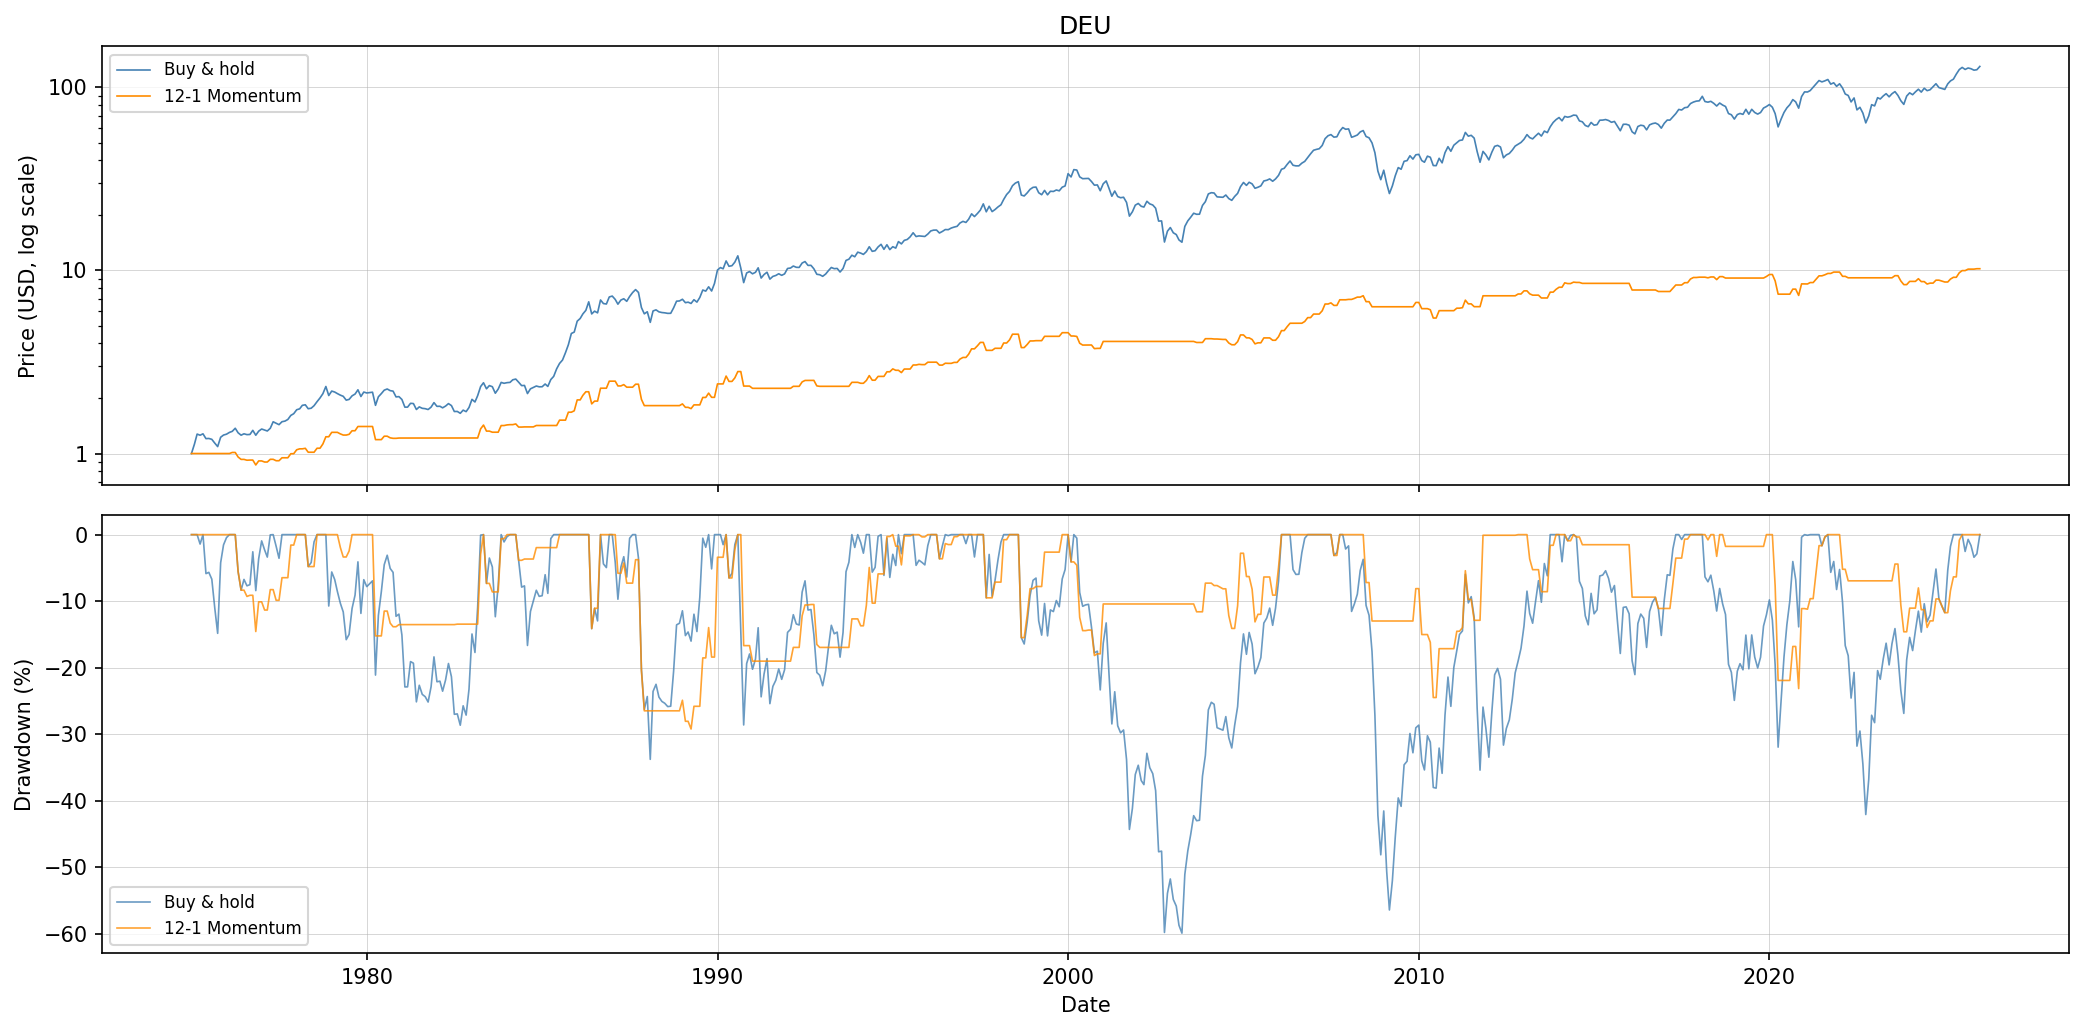

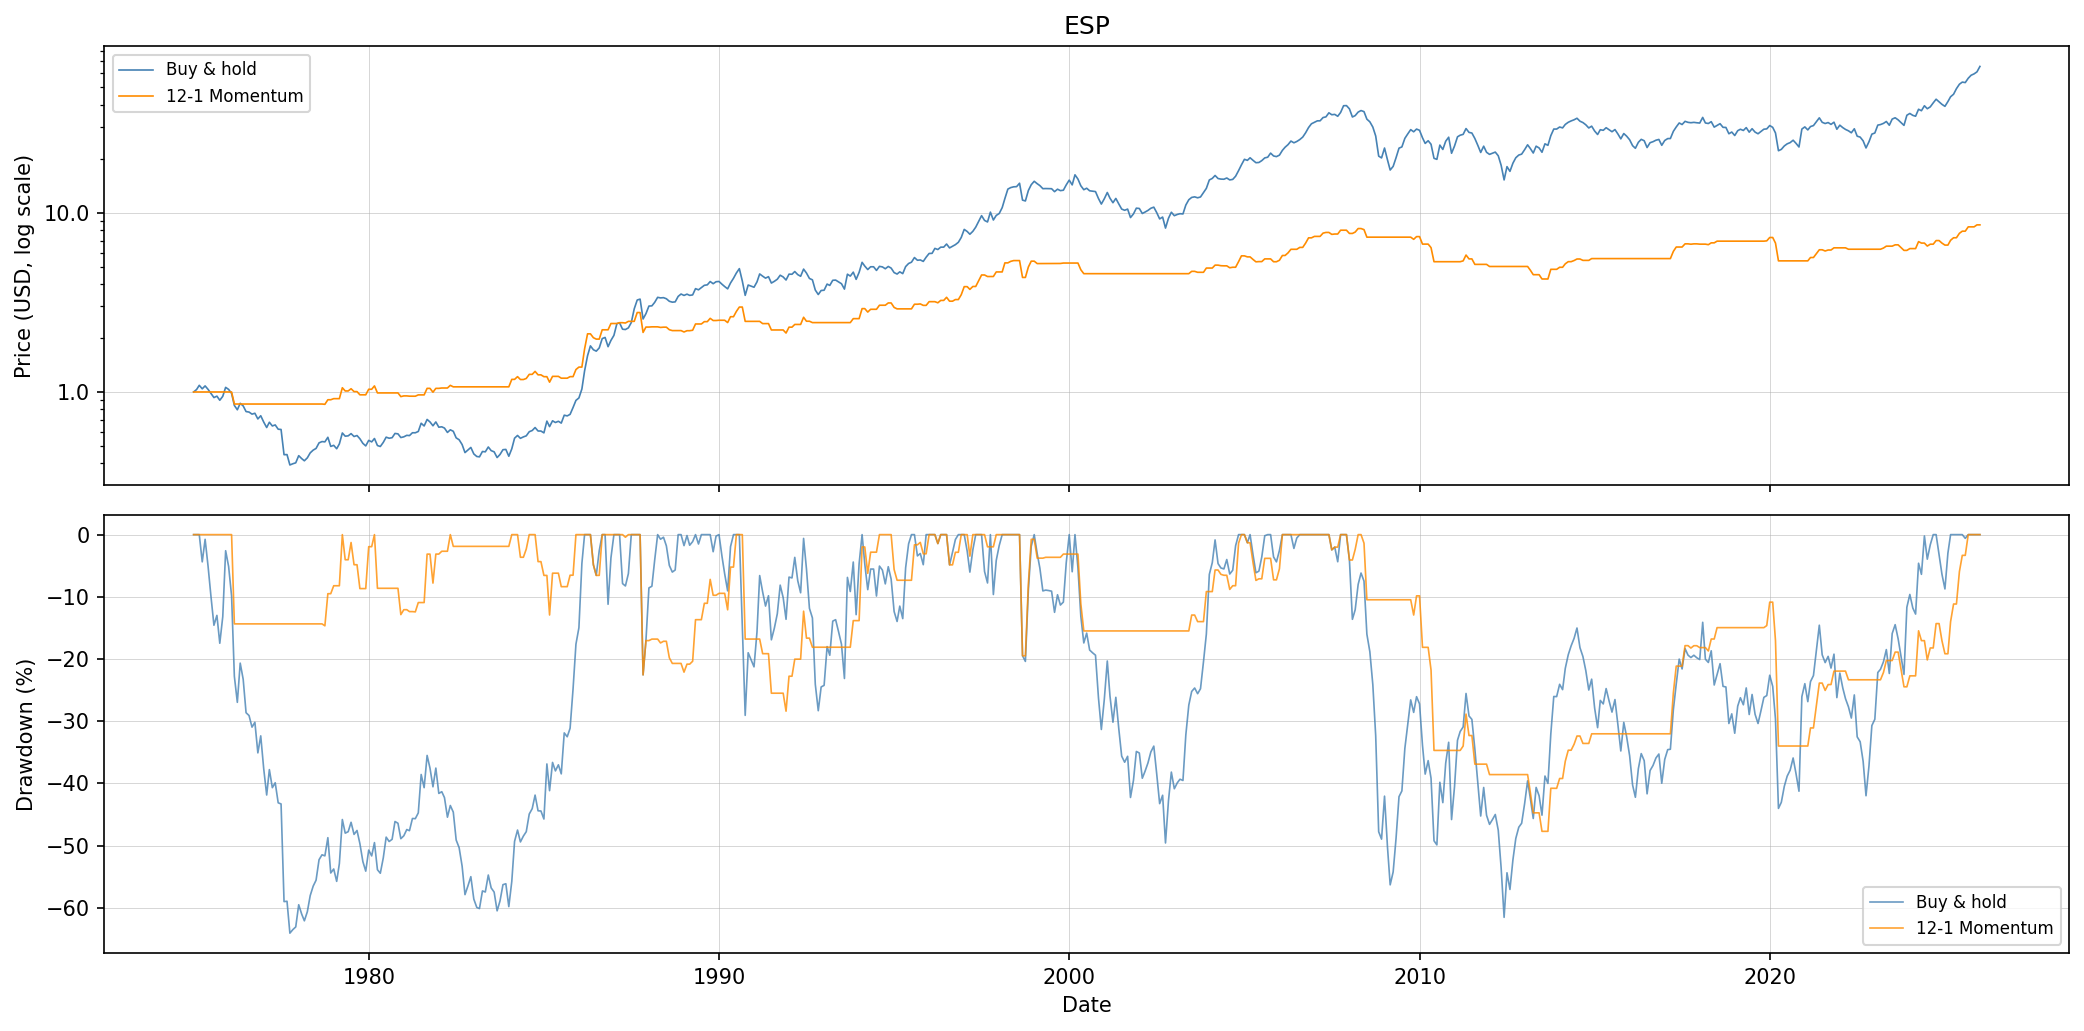

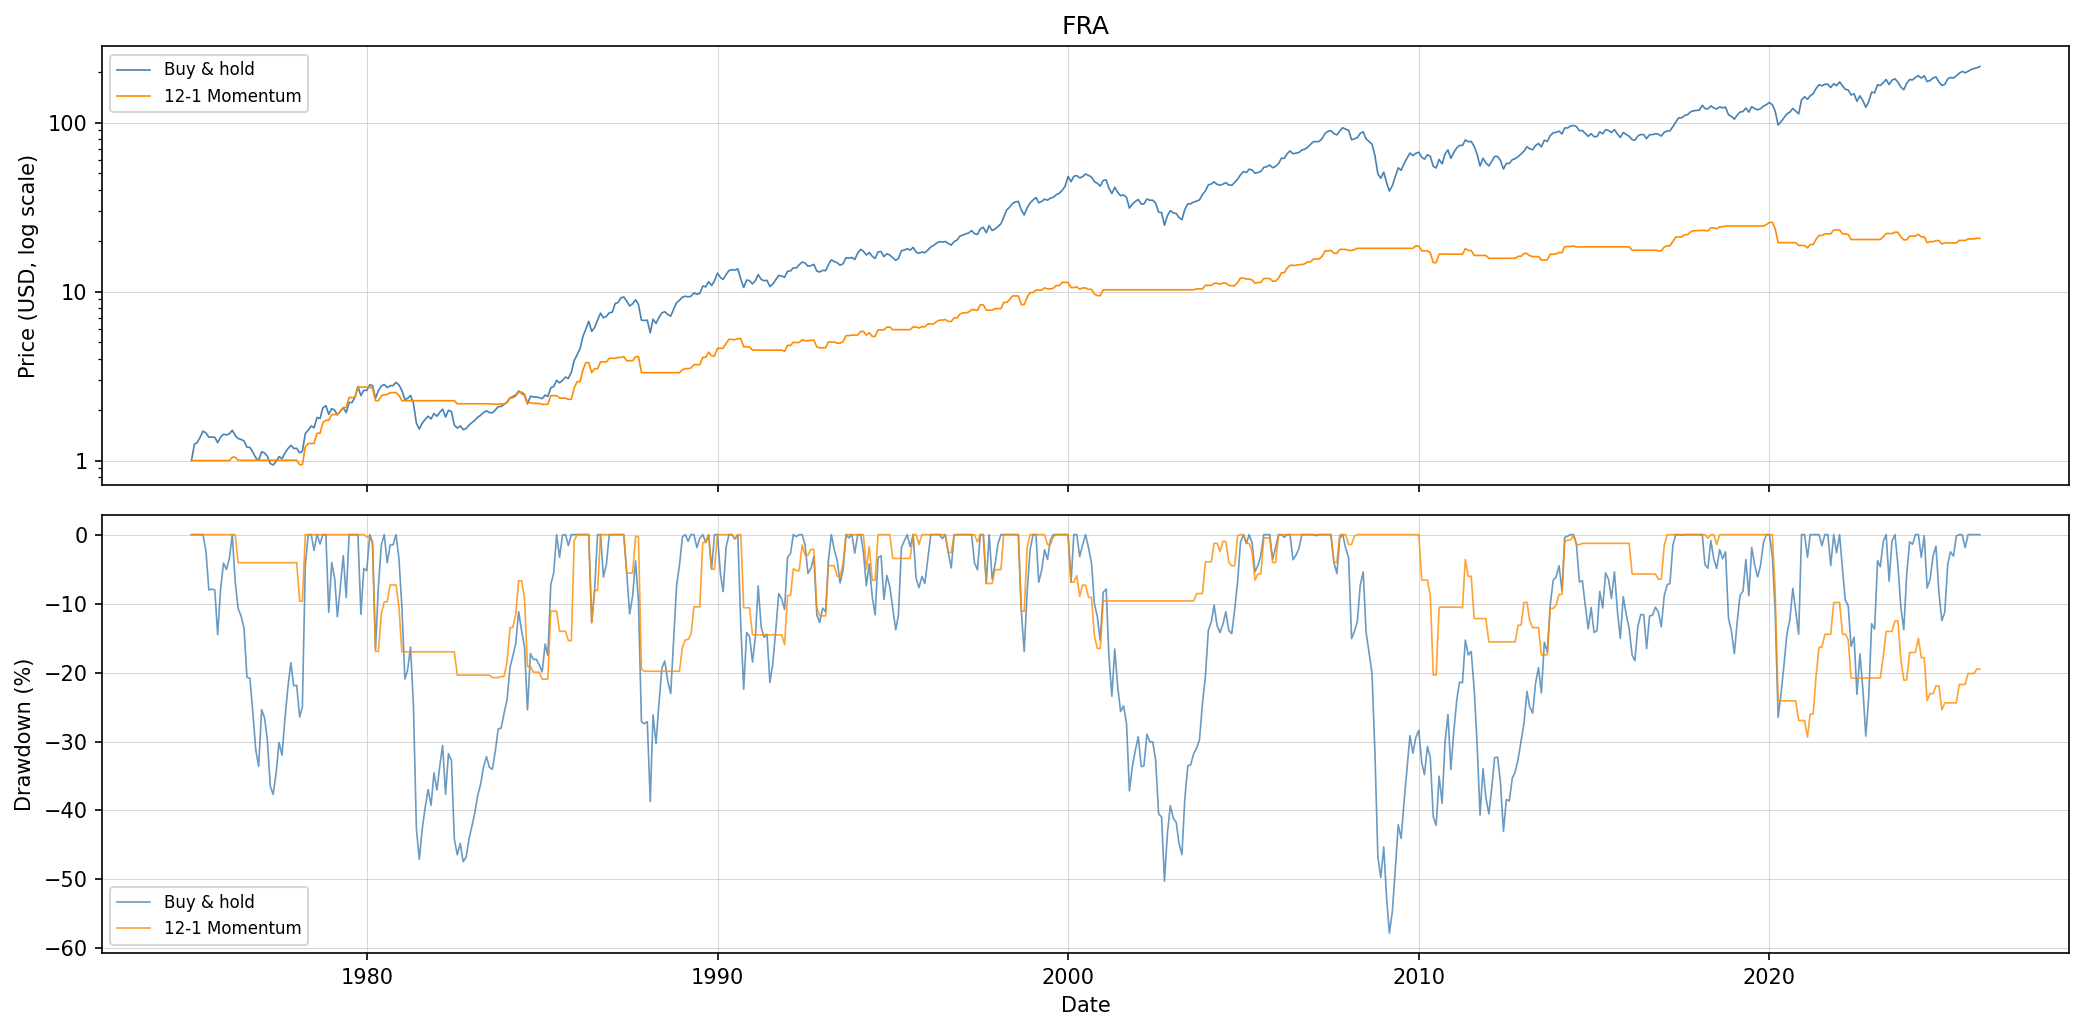

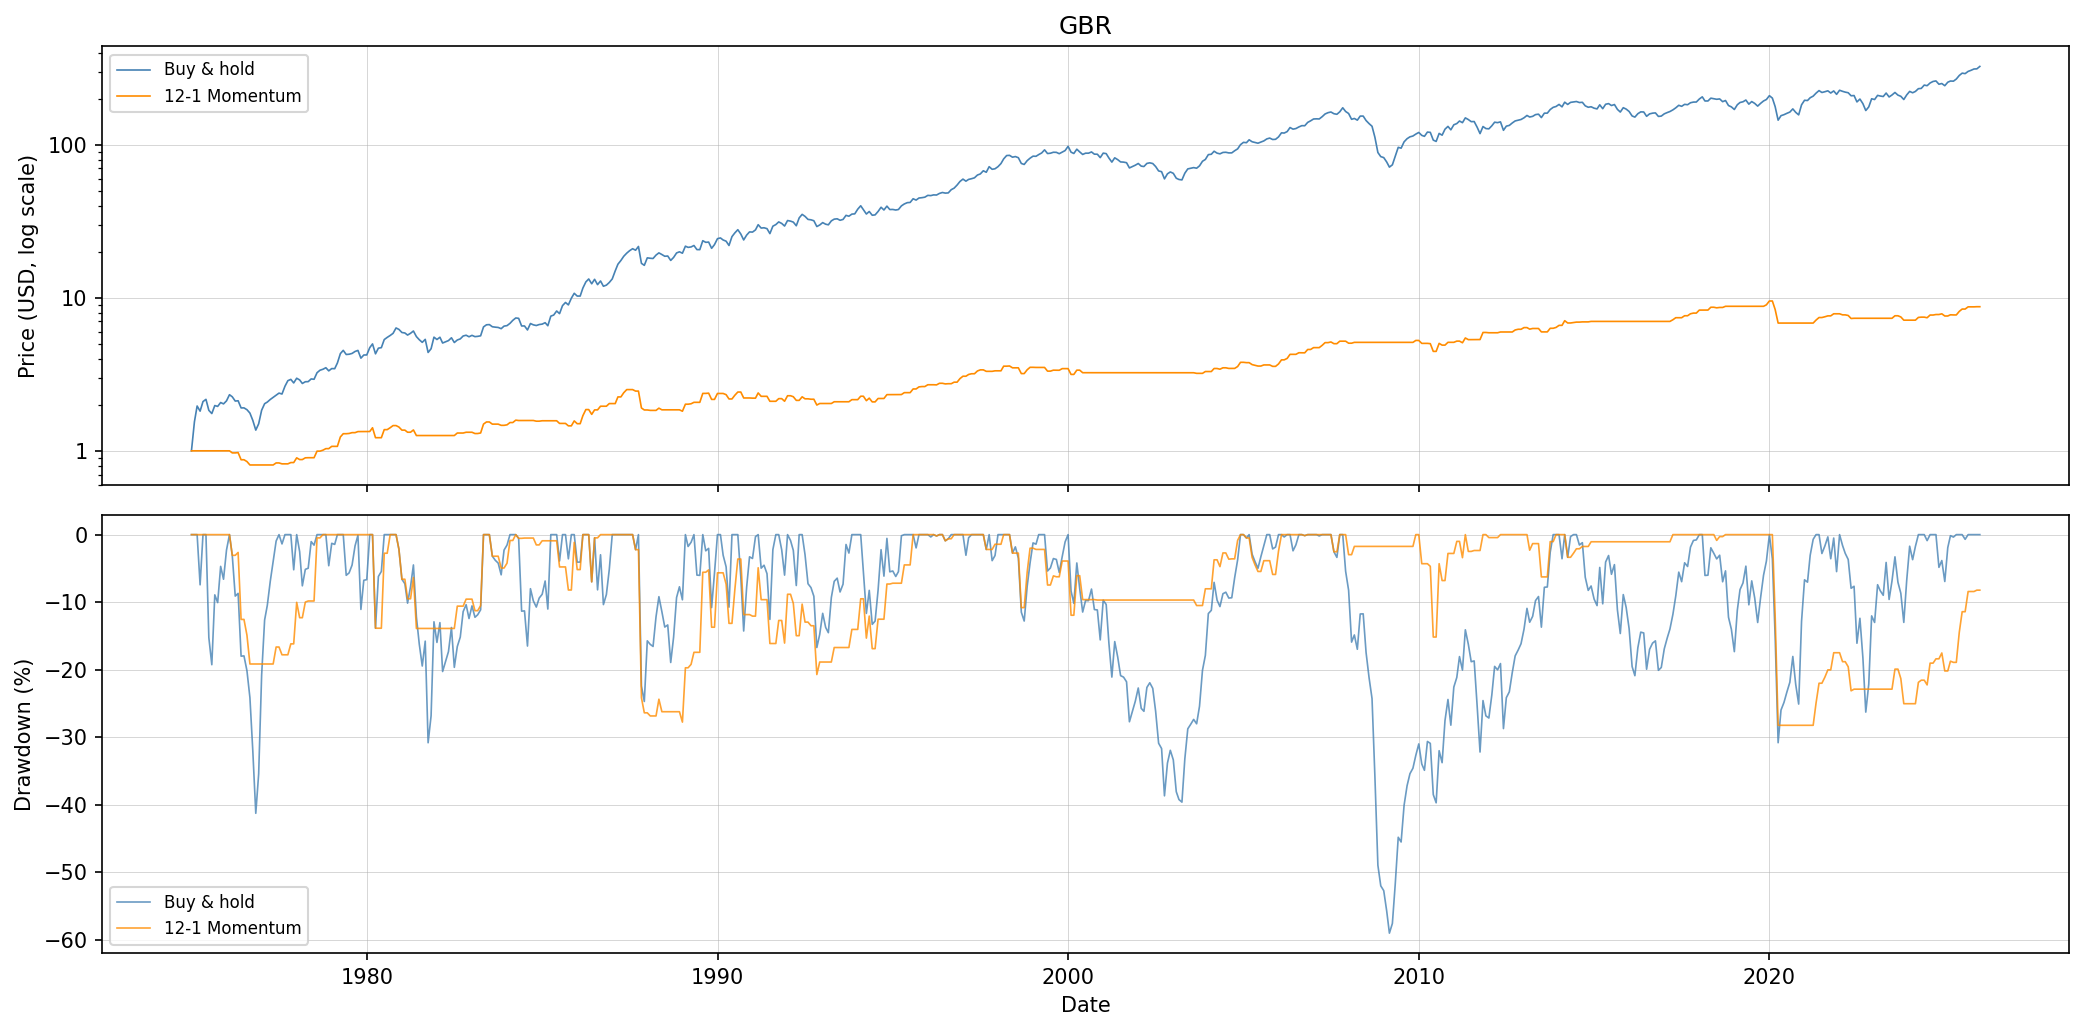

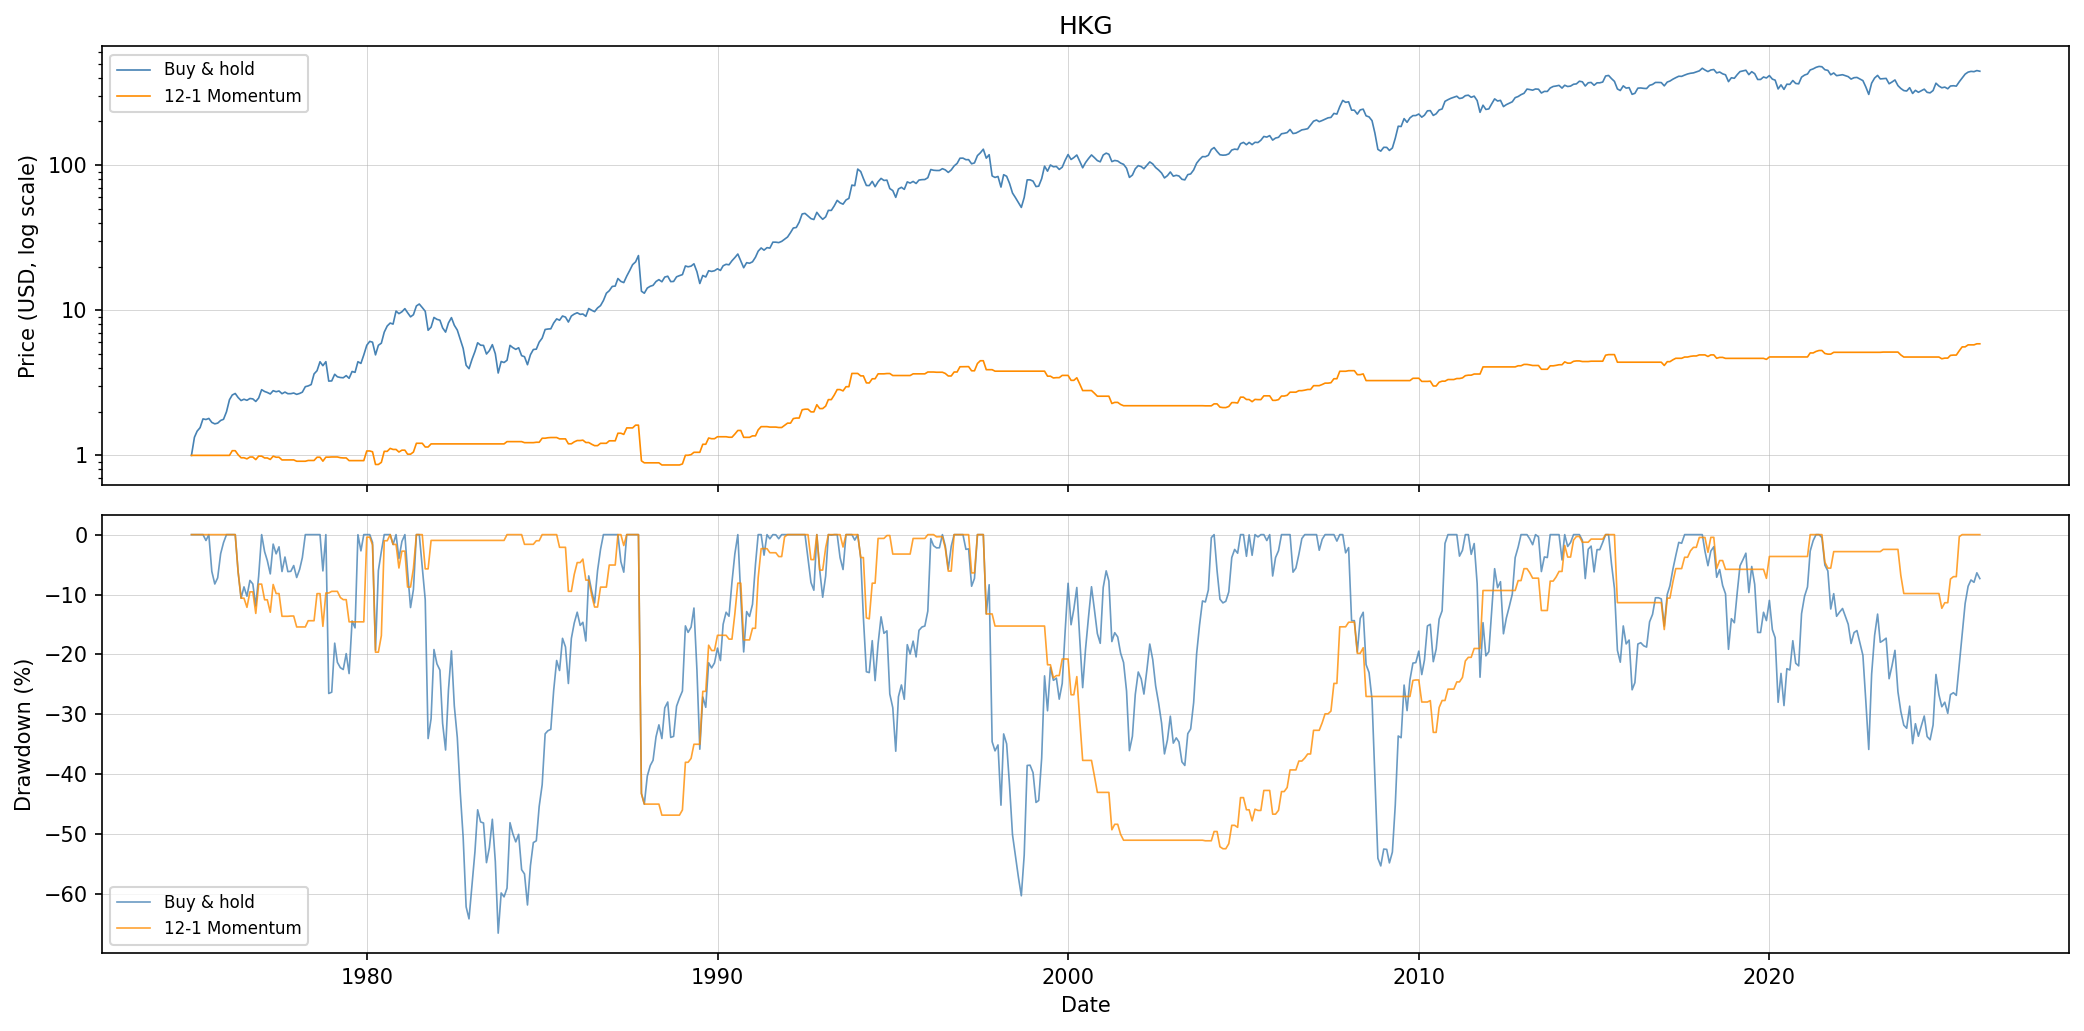

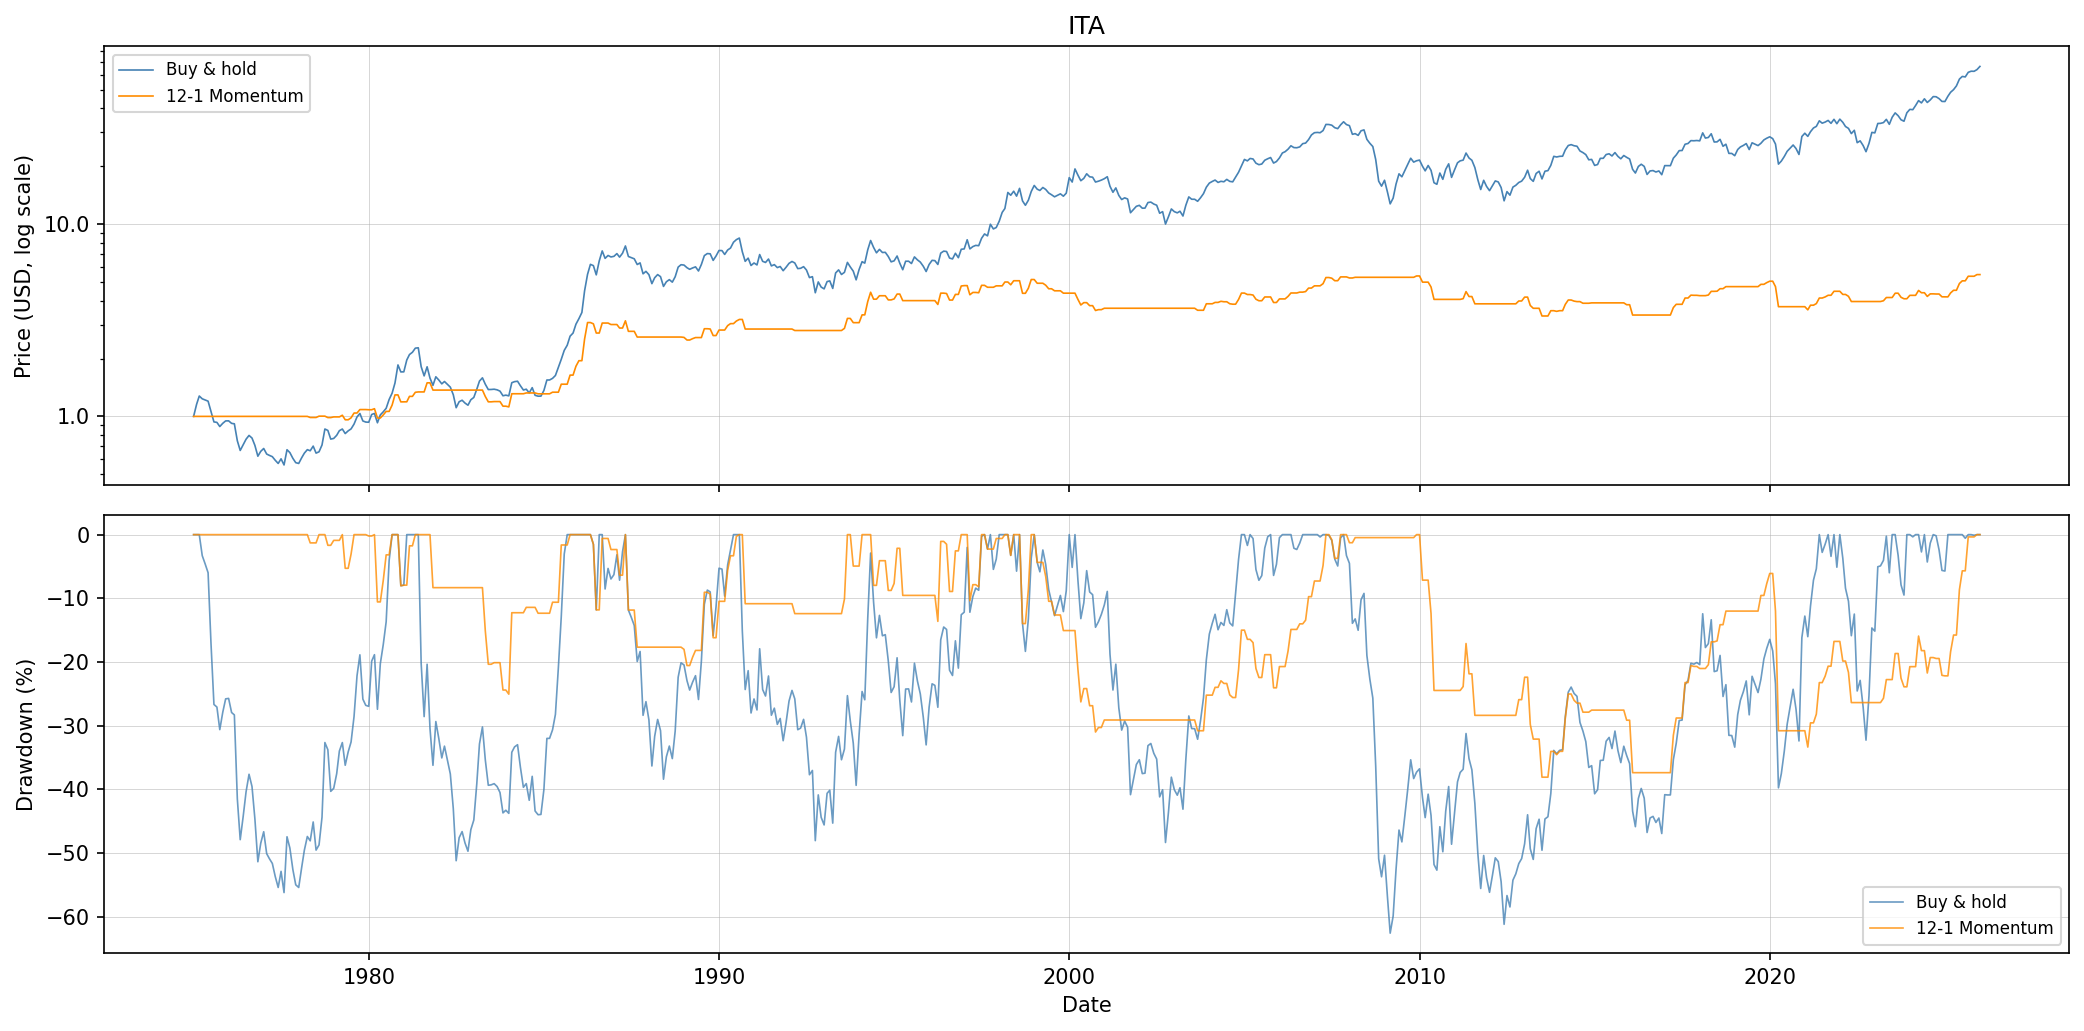

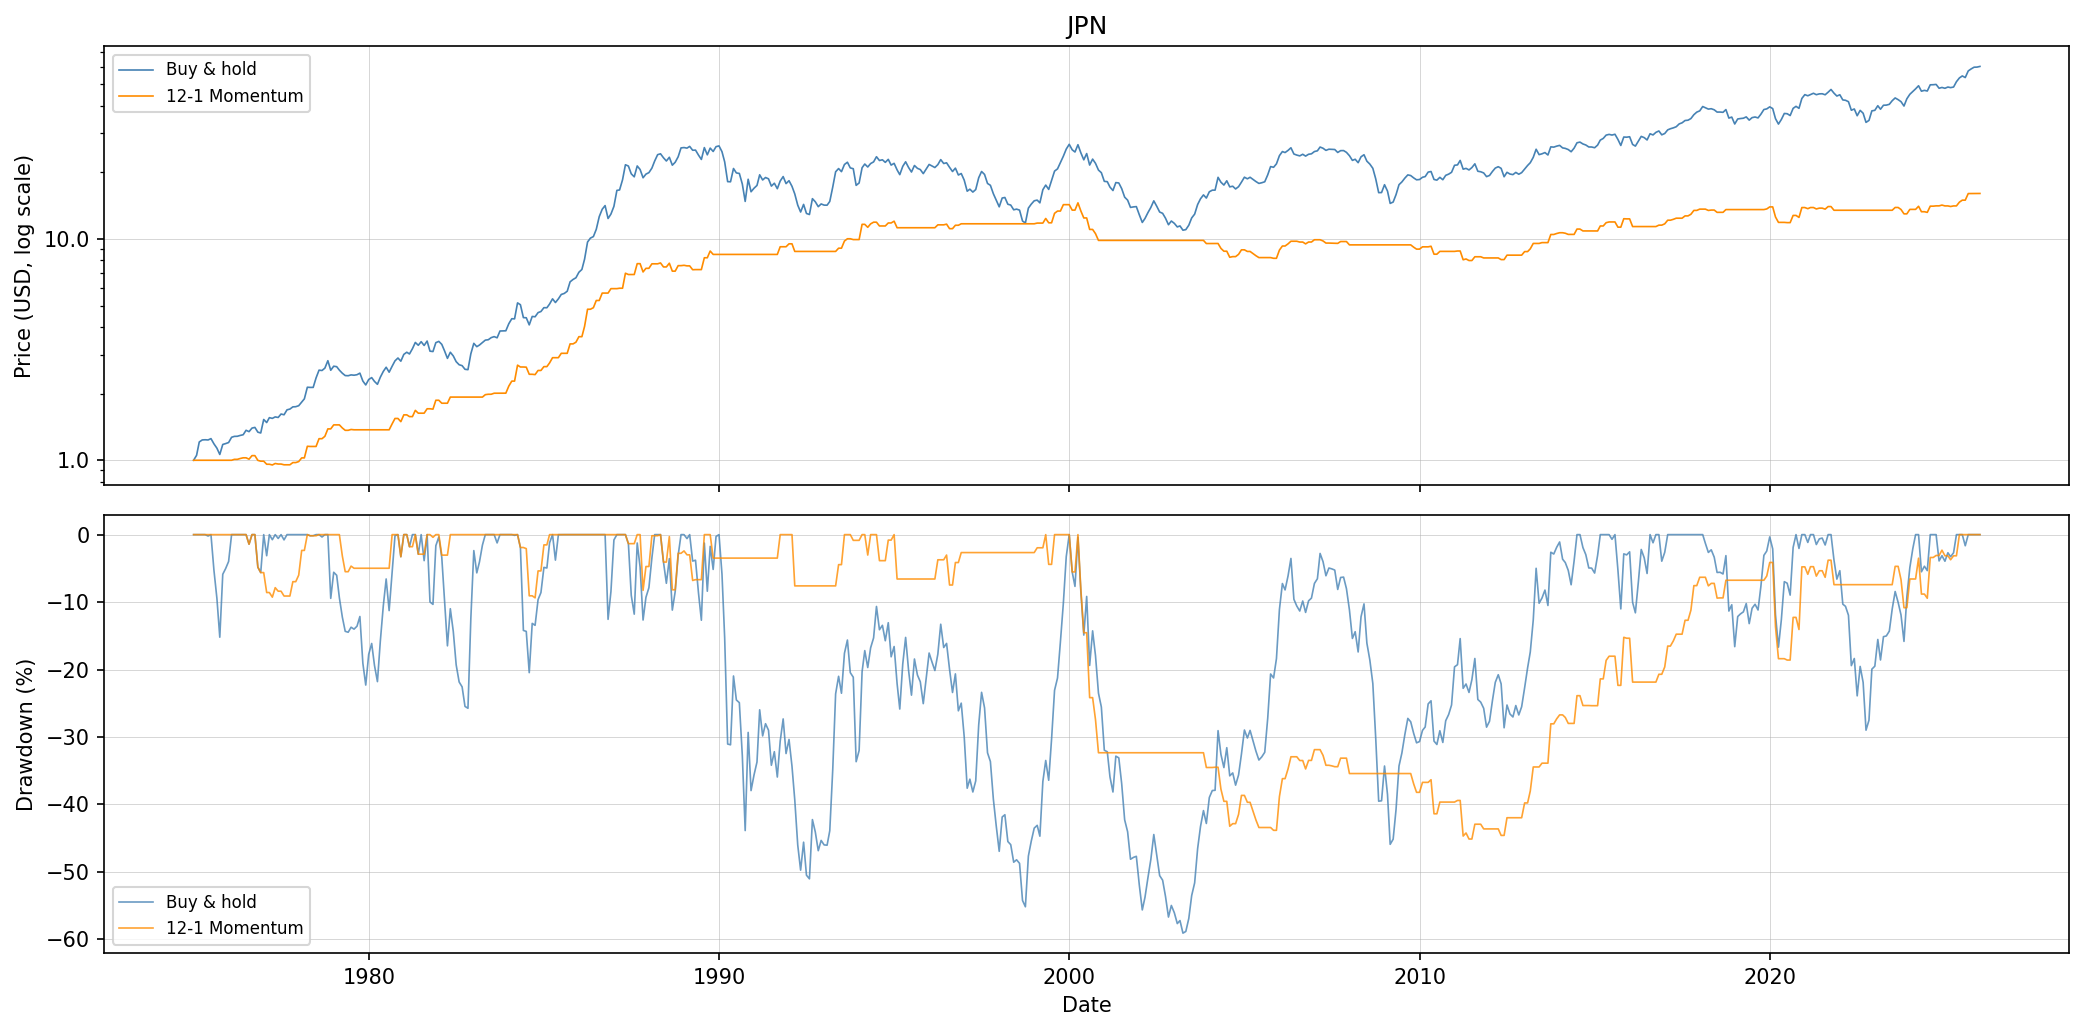

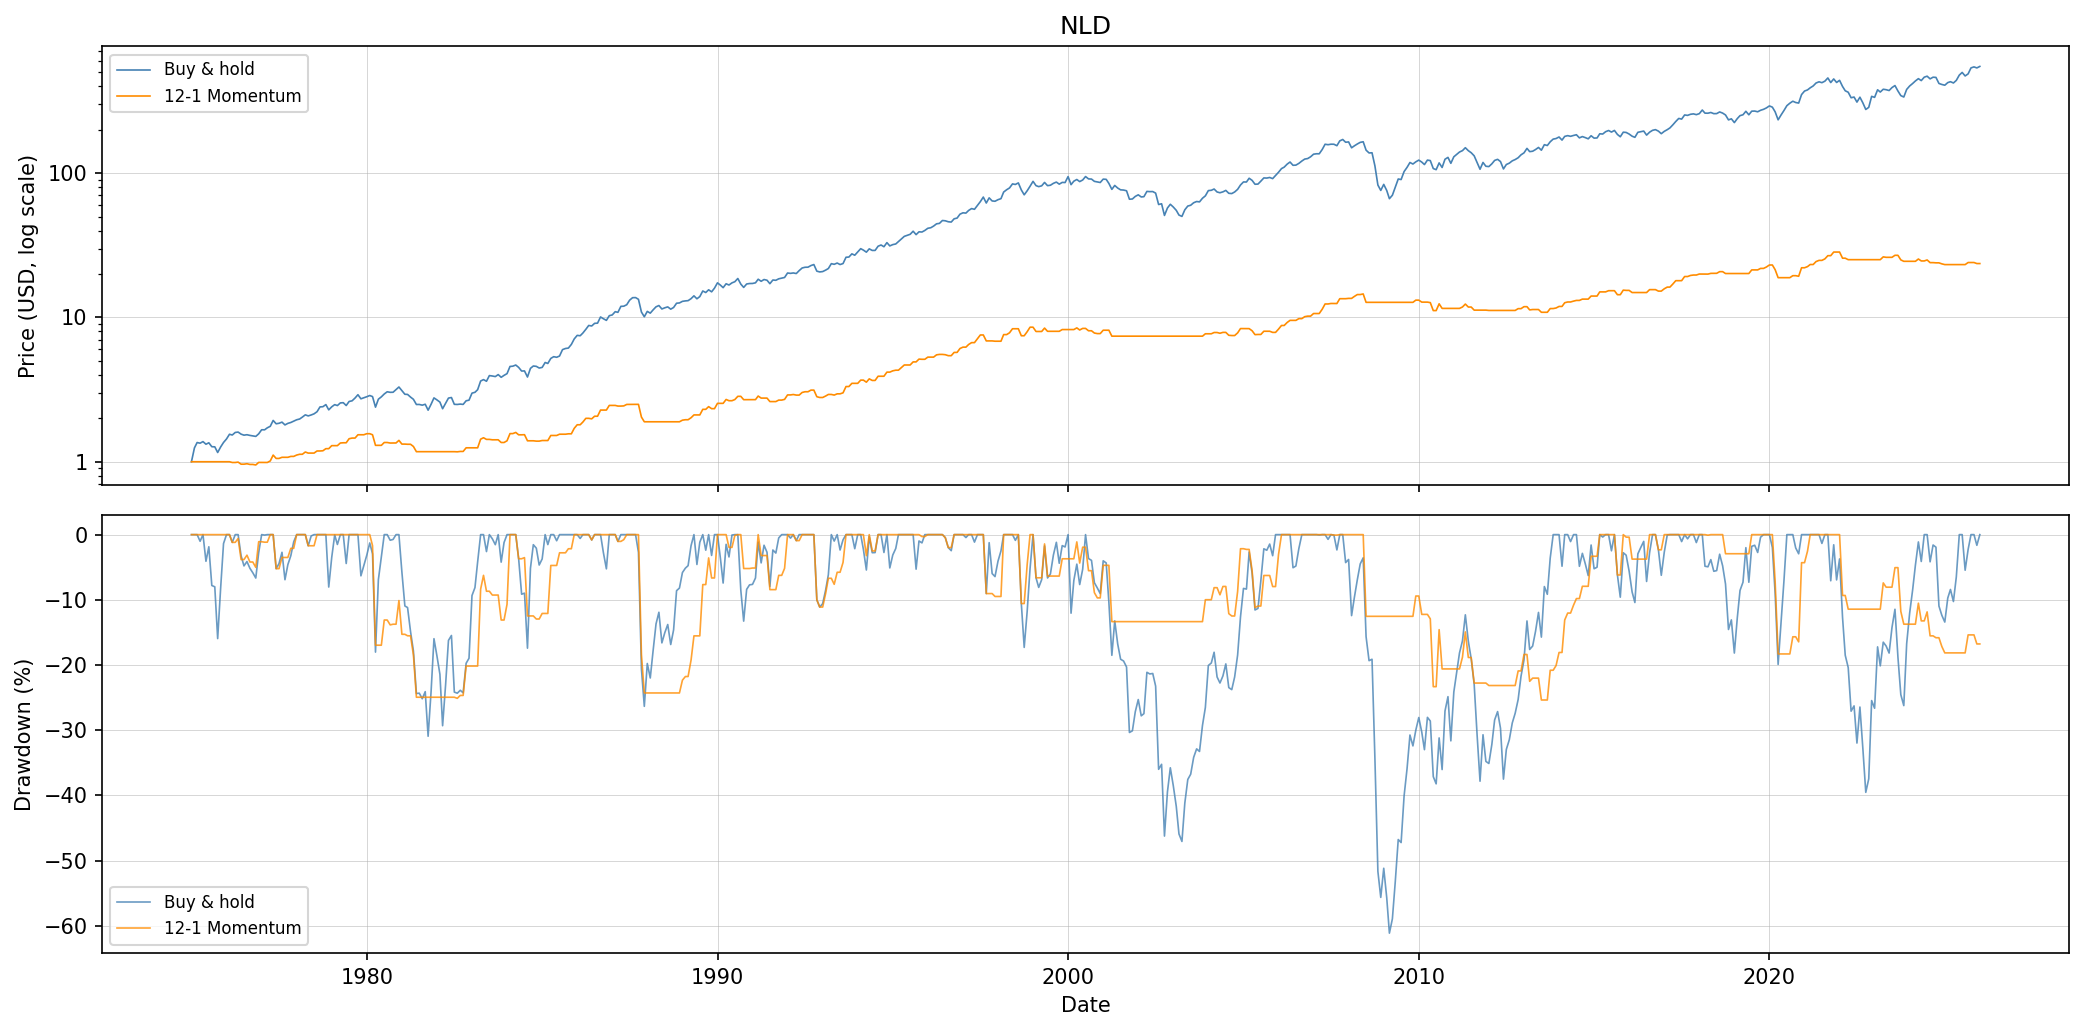

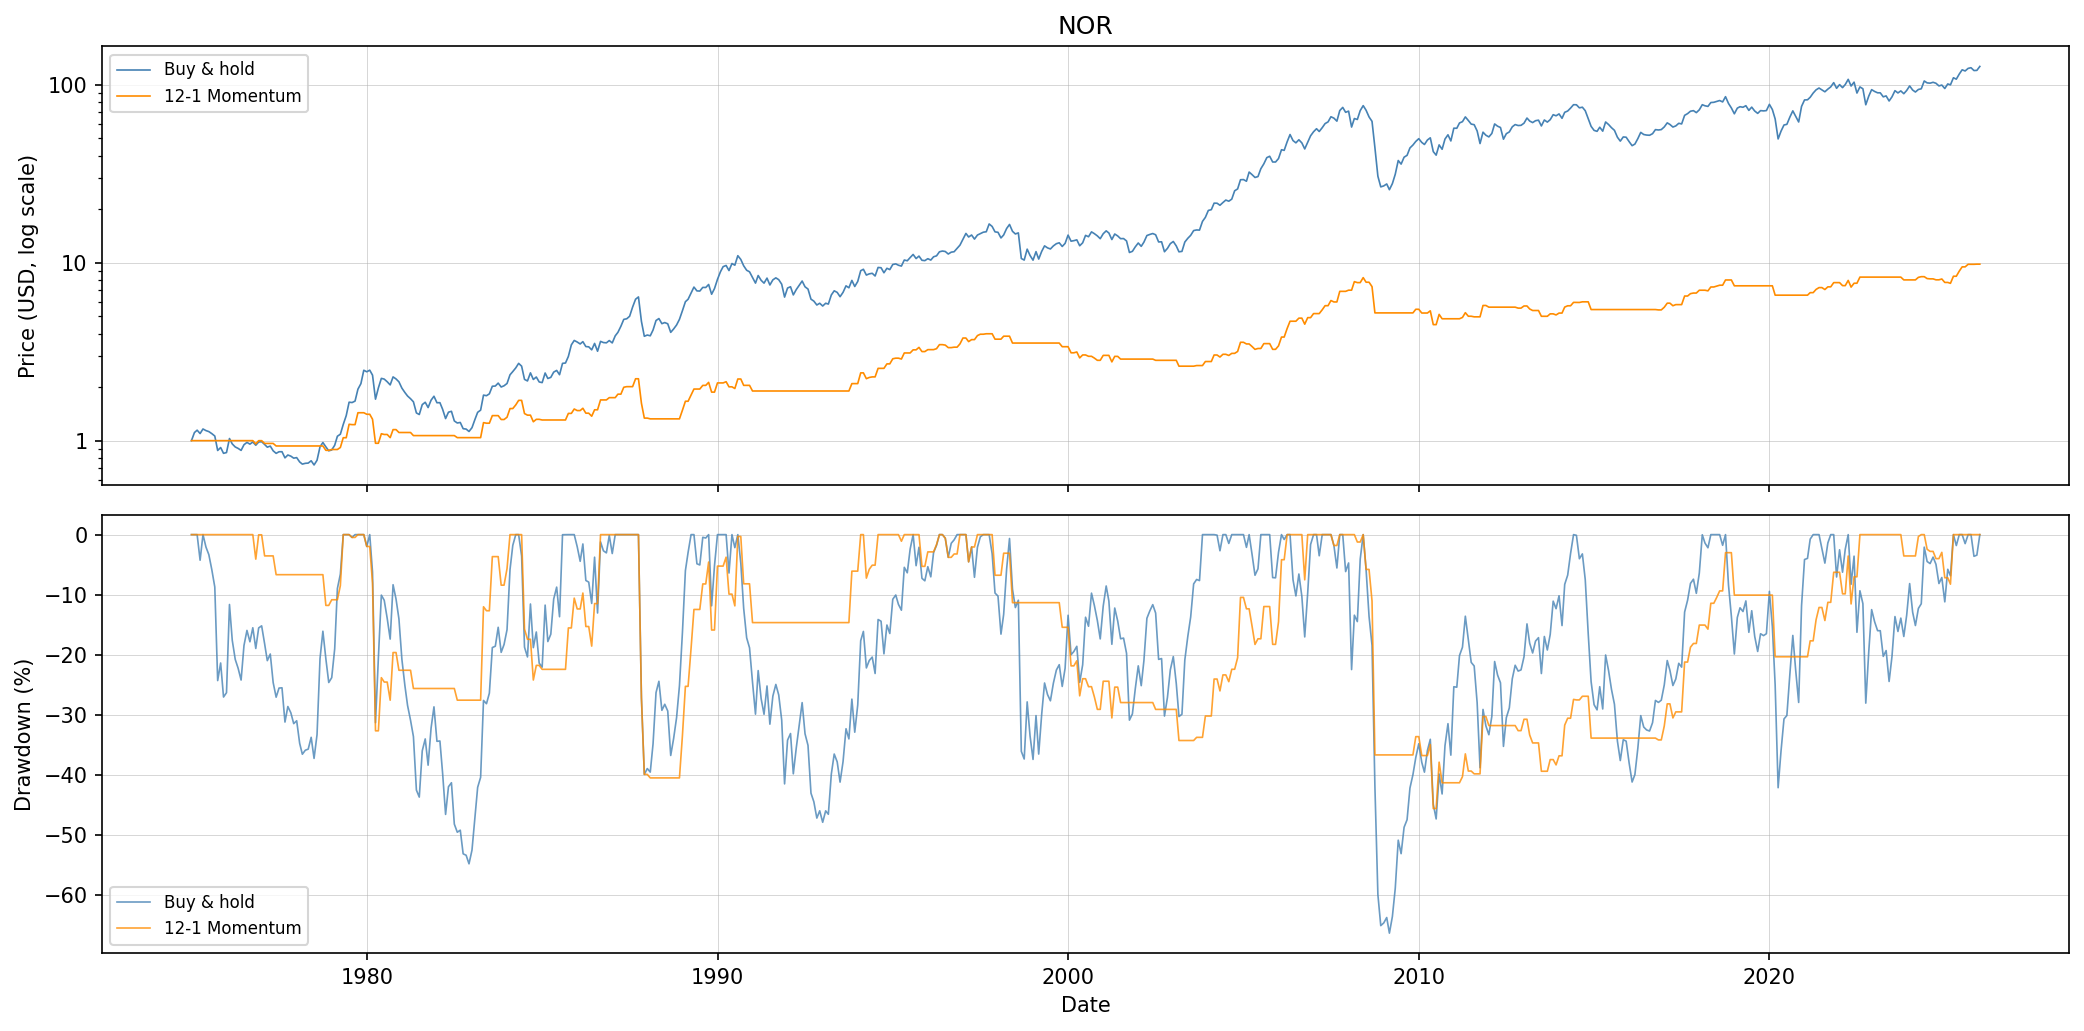

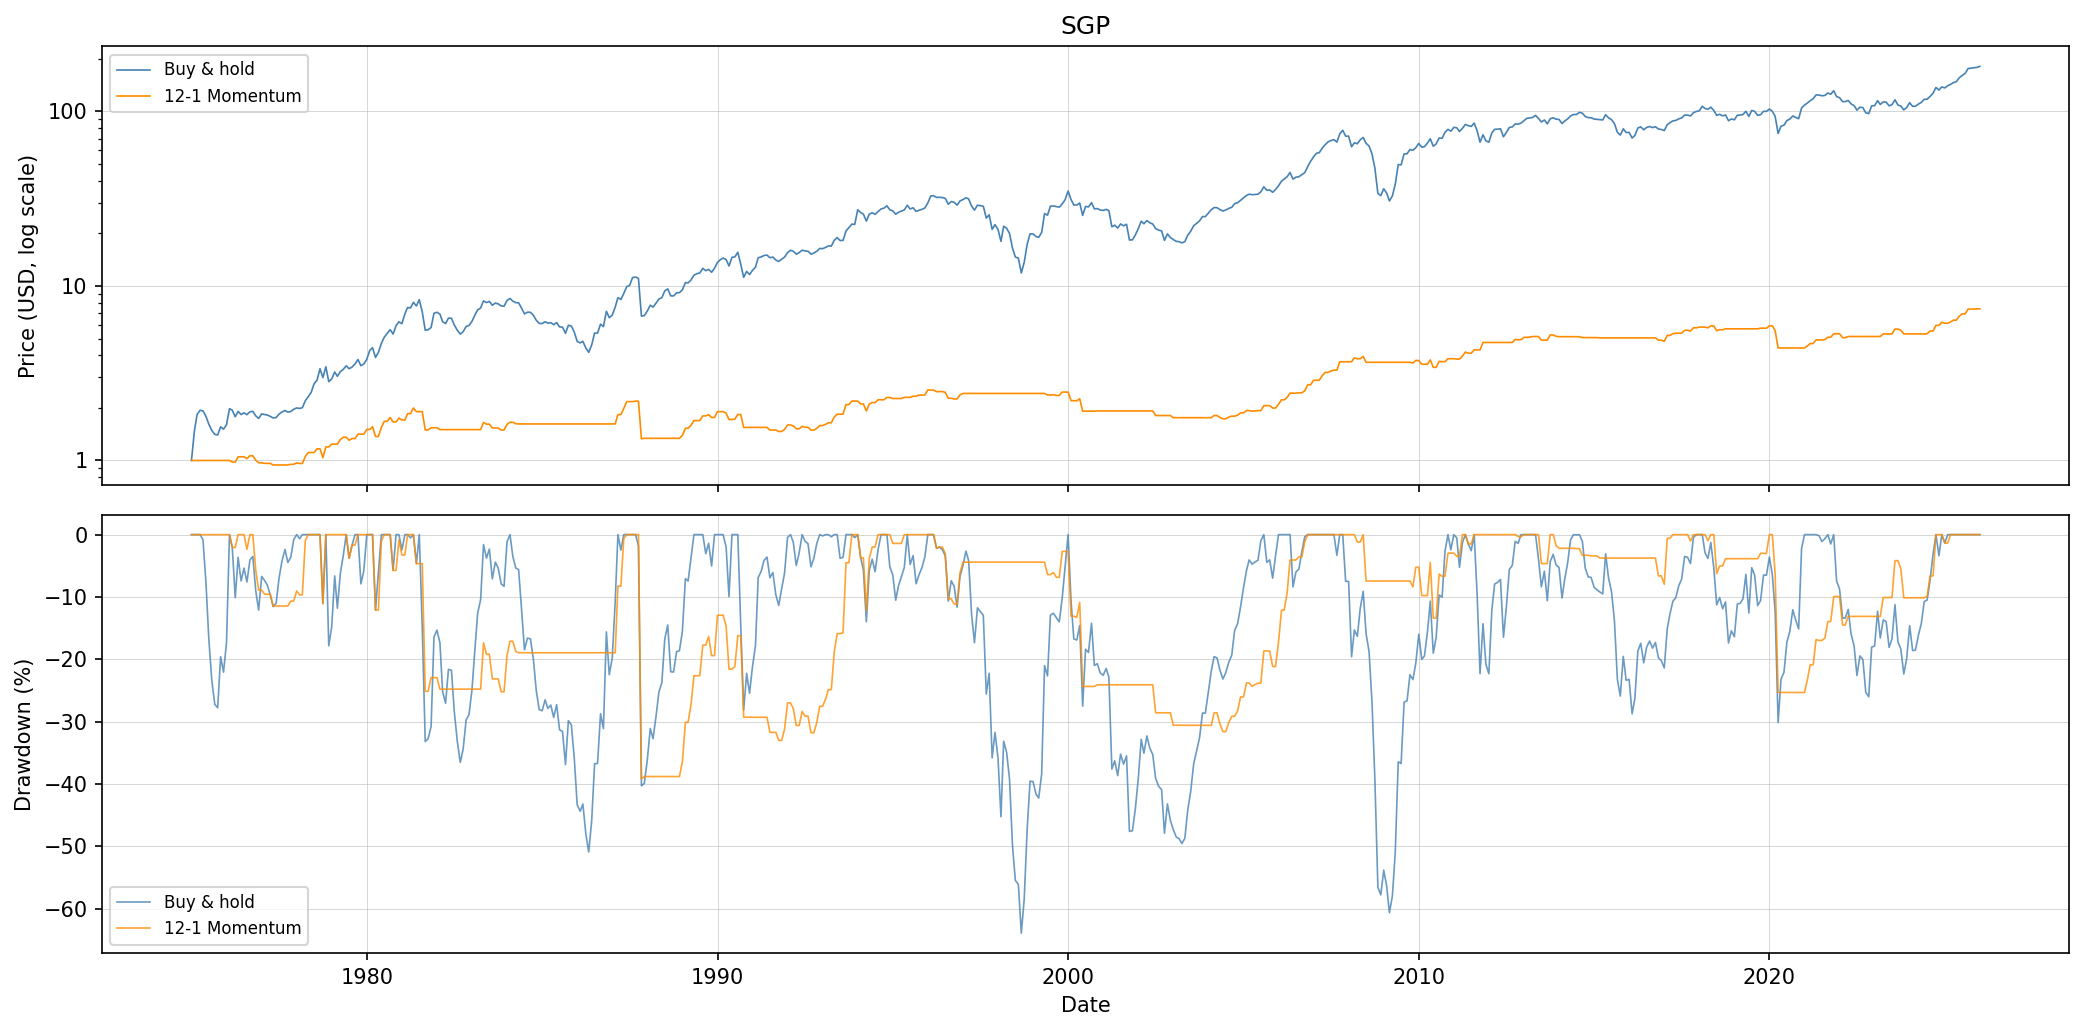

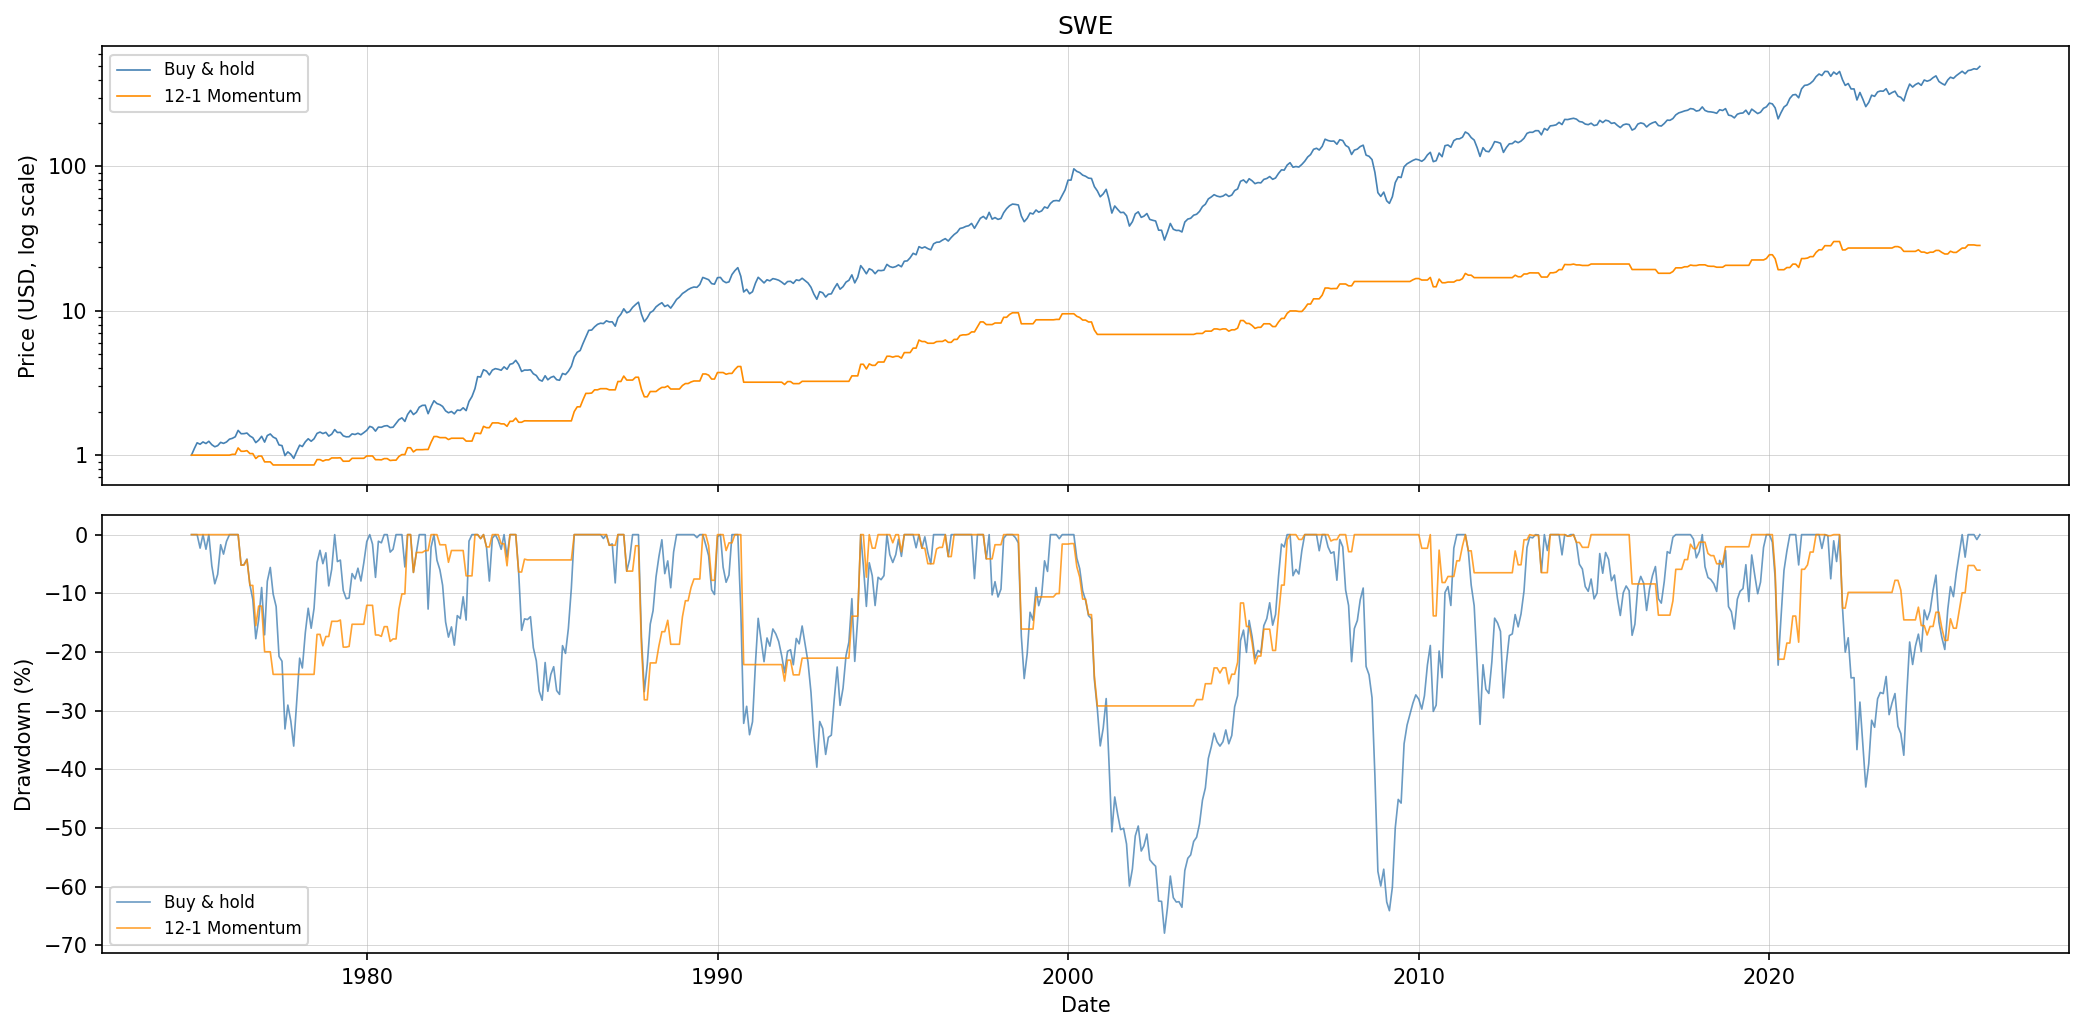

In [14]:
for col in prices.columns:
    dd_orig = compute_drawdowns(prices[col])
    dd_strat = compute_drawdowns(strategy_prices[col])

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

    ax1.plot(prices.index, prices[col], linewidth=0.8, color="steelblue", label="Buy & hold")
    ax1.plot(strategy_prices.index, strategy_prices[col], linewidth=0.8, color="darkorange", label="12-1 Momentum")
    ax1.set_yscale("log")
    ax1.yaxis.set_major_formatter(mticker.ScalarFormatter())
    ax1.set_ylabel("Price (USD, log scale)")
    ax1.set_title(col)
    ax1.legend(fontsize=8)
    ax1.grid(True, linewidth=0.4, alpha=0.6)

    ax2.plot(prices.index, -dd_orig, linewidth=0.8, color="steelblue", alpha=0.8, label="Buy & hold")
    ax2.plot(strategy_prices.index, -dd_strat, linewidth=0.8, color="darkorange", alpha=0.8, label="12-1 Momentum")
    ax2.set_ylabel("Drawdown (%)")
    ax2.set_xlabel("Date")
    ax2.legend(fontsize=8)
    ax2.grid(True, linewidth=0.4, alpha=0.6)

    fig.tight_layout()
    out_path = paths.images_path / f"07_country_tf_{col}.png"
    fig.savefig(out_path, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(out_path)))